In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
# lectura de datos
d = pd.read_csv("/content/icfes_data.csv", sep='\t')

In [3]:
d

,ESTU_CONSECUTIVO,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_TIENEETNIA,ESTU_DEPTO_RESIDE,...,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,ESTU_ESTADOINVESTIGACION,ESTU_GENERACION-E,ESTU_ETNIA,ESTU_PILOPAGA,ESTU_LIMITA_MOTRIZ
0,SB11202040001656,TI,COLOMBIA,M,03/07/2003,20204,ESTUDIANTE,COLOMBIA,No,CALDAS,...,261.0,61.0,61.340840,3.0,3.0,PUBLICAR,NO,NaN,NaN,NaN
1,SB11202040001763,TI,COLOMBIA,F,16/06/2003,20204,ESTUDIANTE,COLOMBIA,No,BOGOTÁ,...,306.0,87.0,71.825844,4.0,4.0,PUBLICAR,NO,NaN,NaN,NaN
2,SB11202040001490,TI,COLOMBIA,F,11/09/2003,20204,ESTUDIANTE,COLOMBIA,No,BOGOTÁ,...,321.0,92.0,57.286312,3.0,3.0,PUBLICAR,NO,NaN,NaN,NaN
3,SB11202040096445,TI,COLOMBIA,M,05/03/2004,20204,ESTUDIANTE,COLOMBIA,No,BOGOTÁ,...,338.0,96.0,67.476602,4.0,4.0,PUBLICAR,NO,NaN,NaN,NaN
4,SB11202040048154,TI,COLOMBIA,M,30/08/2003,20204,ESTUDIANTE,COLOMBIA,No,TOLIMA,...,225.0,35.0,43.877158,2.0,2.0,PUBLICAR,GENERACION E - GRATUIDAD,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30880,SB11202040350649,TI,COLOMBIA,F,04/06/2004,20204,ESTUDIANTE,COLOMBIA,No,CORDOBA,...,275.0,71.0,39.915488,1.0,2.0,PUBLICAR,NO,NaN,NaN,NaN
30881,SB11202040353174,CC,COLOMBIA,M,14/07/2002,20204,ESTUDIANTE,COLOMBIA,No,VALLE,...,294.0,82.0,NaN,NaN,2.0,PUBLICAR,GENERACION E - GRATUIDAD,NaN,NaN,NaN
30882,SB11202040340174,TI,COLOMBIA,F,19/02/2003,20204,ESTUDIANTE,COLOMBIA,No,BOLIVAR,...,192.0,13.0,32.618226,1.0,1.0,PUBLICAR,GENERACION E - GRATUIDAD,NaN,NaN,NaN
30883,SB11202040187506,TI,COLOMBIA,M,23/11/2002,20204,ESTUDIANTE,COLOMBIA,Si,NARIÑO,...,199.0,17.0,26.881639,1.0,1.0,PUBLICAR,NO,NaN,NaN,NaN


In [4]:
# seleccion de las columnas utilies para la elaboracion de nuestro modelo
dn = [
    'PERCENTIL_GLOBAL',
    'PUNT_GLOBAL',
    'PUNT_C_NATURALES',
    'PUNT_LECTURA_CRITICA',
    'ESTU_GENERO',
    'ESTU_ETNIA',
    'ESTU_LIMITA_MOTRIZ',
    'ESTU_HORASSEMANATRABAJA',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_SITUACIONECONOMICA',
    'FAMI_NUMLIBROS',
    'ESTU_DEDICACIONLECTURADIARIA',
    'COLE_NATURALEZA',
    'COLE_BILINGUE',
    'COLE_JORNADA',
    'COLE_AREA_UBICACION',
    'COLE_CARACTER',
    'ESTU_GENERACION-E'
]

In [5]:
# creamos el nuevo data frame con las columnas seleccionadas
df = d[dn]
df


,PERCENTIL_GLOBAL,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,ESTU_GENERO,ESTU_ETNIA,ESTU_LIMITA_MOTRIZ,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,...,FAMI_EDUCACIONPADRE,FAMI_SITUACIONECONOMICA,FAMI_NUMLIBROS,ESTU_DEDICACIONLECTURADIARIA,COLE_NATURALEZA,COLE_BILINGUE,COLE_JORNADA,COLE_AREA_UBICACION,COLE_CARACTER,ESTU_GENERACION-E
0,61.0,261.0,50.0,53,M,NaN,NaN,0,Estrato 5,Si,...,Secundaria (Bachillerato) completa,Peor,0 A 10 LIBROS,30 minutos o menos,NO OFICIAL,N,COMPLETA,URBANO,ACADÉMICO,NO
1,87.0,306.0,63.0,62,F,NaN,NaN,Entre 11 y 20 horas,Estrato 3,Si,...,Postgrado,Igual,MÁS DE 100 LIBROS,30 minutos o menos,NO OFICIAL,N,COMPLETA,URBANO,ACADÉMICO,NO
2,92.0,321.0,63.0,65,F,NaN,NaN,0,Estrato 1,Si,...,Técnica o tecnológica completa,Peor,26 A 100 LIBROS,Entre 30 y 60 minutos,OFICIAL,N,UNICA,URBANO,ACADÉMICO,NO
3,96.0,338.0,75.0,64,M,NaN,NaN,0,Estrato 3,Si,...,Postgrado,Igual,26 A 100 LIBROS,30 minutos o menos,NO OFICIAL,N,COMPLETA,URBANO,ACADÉMICO,NO
4,35.0,225.0,45.0,56,M,NaN,NaN,Entre 11 y 20 horas,Estrato 1,Si,...,Primaria completa,Igual,0 A 10 LIBROS,30 minutos o menos,OFICIAL,N,MAÑANA,URBANO,ACADÉMICO,GENERACION E - GRATUIDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30880,71.0,275.0,56.0,58,F,NaN,NaN,0,Estrato 2,No,...,Primaria completa,Igual,11 A 25 LIBROS,30 minutos o menos,OFICIAL,N,MAÑANA,RURAL,ACADÉMICO,NO
30881,82.0,294.0,59.0,59,M,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,OFICIAL,N,MAÑANA,URBANO,TÉCNICO/ACADÉMICO,GENERACION E - GRATUIDAD
30882,13.0,192.0,40.0,43,F,NaN,NaN,0,Estrato 2,No,...,Primaria incompleta,Igual,0 A 10 LIBROS,Entre 30 y 60 minutos,OFICIAL,N,MAÑANA,RURAL,ACADÉMICO,GENERACION E - GRATUIDAD
30883,17.0,199.0,45.0,34,M,NaN,NaN,Menos de 10 horas,Sin Estrato,No,...,Primaria incompleta,Igual,0 A 10 LIBROS,30 minutos o menos,OFICIAL,N,MAÑANA,RURAL,TÉCNICO/ACADÉMICO,NO


In [7]:
# limpiamos el puntaje global para garantizar que sea 100% numerico
df['PUNT_GLOBAL'] = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce')

# Eliminamos filas que tengan el puntaje global vacío
df = df.dropna(subset=['PUNT_GLOBAL']).copy()


/tmp/ipykernel_52715/2294241992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PUNT_GLOBAL'] = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce')


In [9]:
# definimos el umbral para pasar a medicina
umbral_real_medicina = 400

In [10]:
# creamos la variable dummy que determina si el estudiante pasa o no a medicina con base al umbral de 400 pts (variable objetivo)
df['PASO_MEDICINA'] = np.where(df['PUNT_GLOBAL'] >= umbral_real_medicina, 1, 0)

In [11]:
df

,PERCENTIL_GLOBAL,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,ESTU_GENERO,ESTU_ETNIA,ESTU_LIMITA_MOTRIZ,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,...,FAMI_SITUACIONECONOMICA,FAMI_NUMLIBROS,ESTU_DEDICACIONLECTURADIARIA,COLE_NATURALEZA,COLE_BILINGUE,COLE_JORNADA,COLE_AREA_UBICACION,COLE_CARACTER,ESTU_GENERACION-E,PASO_MEDICINA
0,61.0,261.0,50.0,53,M,NaN,NaN,0,Estrato 5,Si,...,Peor,0 A 10 LIBROS,30 minutos o menos,NO OFICIAL,N,COMPLETA,URBANO,ACADÉMICO,NO,0
1,87.0,306.0,63.0,62,F,NaN,NaN,Entre 11 y 20 horas,Estrato 3,Si,...,Igual,MÁS DE 100 LIBROS,30 minutos o menos,NO OFICIAL,N,COMPLETA,URBANO,ACADÉMICO,NO,0
2,92.0,321.0,63.0,65,F,NaN,NaN,0,Estrato 1,Si,...,Peor,26 A 100 LIBROS,Entre 30 y 60 minutos,OFICIAL,N,UNICA,URBANO,ACADÉMICO,NO,0
3,96.0,338.0,75.0,64,M,NaN,NaN,0,Estrato 3,Si,...,Igual,26 A 100 LIBROS,30 minutos o menos,NO OFICIAL,N,COMPLETA,URBANO,ACADÉMICO,NO,0
4,35.0,225.0,45.0,56,M,NaN,NaN,Entre 11 y 20 horas,Estrato 1,Si,...,Igual,0 A 10 LIBROS,30 minutos o menos,OFICIAL,N,MAÑANA,URBANO,ACADÉMICO,GENERACION E - GRATUIDAD,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30879,60.0,258.0,48.0,57,M,NaN,NaN,0,Estrato 1,No,...,Peor,0 A 10 LIBROS,Entre 30 y 60 minutos,OFICIAL,N,MAÑANA,URBANO,ACADÉMICO,GENERACION E - GRATUIDAD,0
30880,71.0,275.0,56.0,58,F,NaN,NaN,0,Estrato 2,No,...,Igual,11 A 25 LIBROS,30 minutos o menos,OFICIAL,N,MAÑANA,RURAL,ACADÉMICO,NO,0
30881,82.0,294.0,59.0,59,M,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,OFICIAL,N,MAÑANA,URBANO,TÉCNICO/ACADÉMICO,GENERACION E - GRATUIDAD,0
30882,13.0,192.0,40.0,43,F,NaN,NaN,0,Estrato 2,No,...,Igual,0 A 10 LIBROS,Entre 30 y 60 minutos,OFICIAL,N,MAÑANA,RURAL,ACADÉMICO,GENERACION E - GRATUIDAD,0


In [23]:
#ANALISIS EXPLORATORIO
# a) analisis de estructura y calidad de datos

# dimensiones del dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# tipos de datos
print(df.info())

# conteo de valores nulos en las variables
variables_clave = [
    'PUNT_GLOBAL', 'FAMI_ESTRATOVIVIENDA', 'COLE_NATURALEZA',
    'FAMI_TIENEINTERNET', 'FAMI_EDUCACIONMADRE', 'PASO_MEDICINA'
]
print("\n• Valores faltantes (nulos) por variable clave elegida:")
print(df[variables_clave].isnull().sum())

El dataset tiene 30884 filas y 23 columnas.
<class 'pandas.core.frame.DataFrame'>
Index: 30884 entries, 0 to 30883
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PERCENTIL_GLOBAL              30884 non-null  float64
 1   PUNT_GLOBAL                   30884 non-null  float64
 2   PUNT_C_NATURALES              30884 non-null  float64
 3   PUNT_LECTURA_CRITICA          30884 non-null  int64  
 4   ESTU_GENERO                   30884 non-null  object 
 5   ESTU_ETNIA                    0 non-null      float64
 6   ESTU_LIMITA_MOTRIZ            0 non-null      float64
 7   ESTU_HORASSEMANATRABAJA       29775 non-null  object 
 8   FAMI_ESTRATOVIVIENDA          29776 non-null  object 
 9   FAMI_TIENEINTERNET            29969 non-null  object 
 10  FAMI_TIENECOMPUTADOR          29581 non-null  object 
 11  FAMI_EDUCACIONMADRE           29974 non-null  object 
 12  FAMI_EDUCACIONPADRE  

/tmp/ipykernel_52715/4074611958.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PASO_MEDICINA', data=df, palette='viridis')


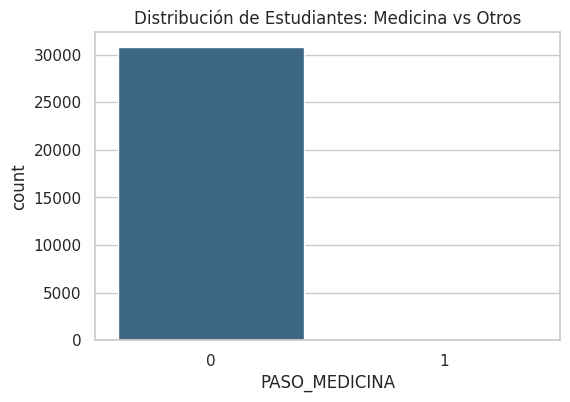

PASO_MEDICINA
0    99.753918
1     0.246082
Name: proportion, dtype: float64


In [21]:
# b) analisis de la variable independiente
plt.figure(figsize=(6,4))
sns.countplot(x='PASO_MEDICINA', data=df, palette='viridis')
plt.title('Distribución de Estudiantes: Medicina vs Otros')
plt.show()

print(df['PASO_MEDICINA'].value_counts(normalize=True) * 100)


--- PASO 2: Análisis Univariado ---

• Resumen estadístico del Puntaje Global a nivel nacional:
count    30884.000000
mean       248.422225
std         48.598912
min          0.000000
25%        212.000000
50%        245.000000
75%        282.000000
max        473.000000
Name: PUNT_GLOBAL, dtype: float64

• Diagnóstico de la Variable Dummy (PASO_MEDICINA):
  - No Pasa (<400): 30,808 estudiantes (99.754%)
  - Pasa a Medicina (>=400): 76 estudiantes (0.246%)


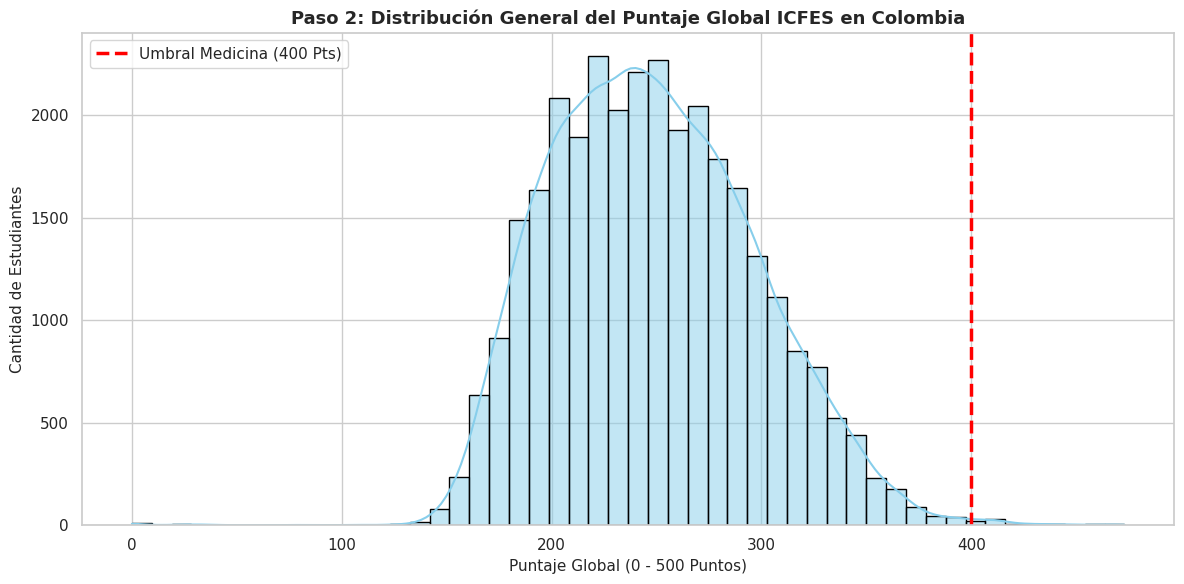

In [24]:
# c) analisis univariado
print("\n--- PASO 2: Análisis Univariado ---")
#  Distribución estadística de la variable numérica principal
print("\n• Resumen estadístico del Puntaje Global a nivel nacional:")
print(df['PUNT_GLOBAL'].describe())

# Diagnóstico de Desbalanceo de Clases (Variable Objetivo)
print("\n• Diagnóstico de la Variable Dummy (PASO_MEDICINA):")
conteo_clases = df['PASO_MEDICINA'].value_counts()
porcentaje_clases = df['PASO_MEDICINA'].value_counts(normalize=True) * 100
for cat in conteo_clases.index:
    estado = "Pasa a Medicina (>=400)" if cat == 1 else "No Pasa (<400)"
    print(f"  - {estado}: {conteo_clases[cat]:,} estudiantes ({porcentaje_clases[cat]:.3f}%)")

# Gráfica Univariada: Distribución del Puntaje Global del examen
plt.figure()
sns.histplot(df['PUNT_GLOBAL'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.axvline(x=400, color='red', linestyle='--', linewidth=2.5, label='Umbral Medicina (400 Pts)')
plt.title('Paso 2: Distribución General del Puntaje Global ICFES en Colombia', fontsize=13, fontweight='bold')
plt.xlabel('Puntaje Global (0 - 500 Puntos)', fontsize=11)
plt.ylabel('Cantidad de Estudiantes', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


- Análisis Bivariado y Multivariado
Tasa de éxito para Medicina (>=400 puntos) según el Estrato de Vivienda:
FAMI_ESTRATOVIVIENDA
Estrato 1      0.107 %
Estrato 2      0.117 %
Estrato 3      0.389 %
Estrato 4      1.464 %
Estrato 5      1.711 %
Estrato 6        0.0 %
Sin Estrato      0.0 %
Name: PASO_MEDICINA, dtype: object


/tmp/ipykernel_52715/2216956582.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FAMI_ESTRATOVIVIENDA', y='PUNT_GLOBAL', data=df, order=orden_estrato, palette="YlGnBu")


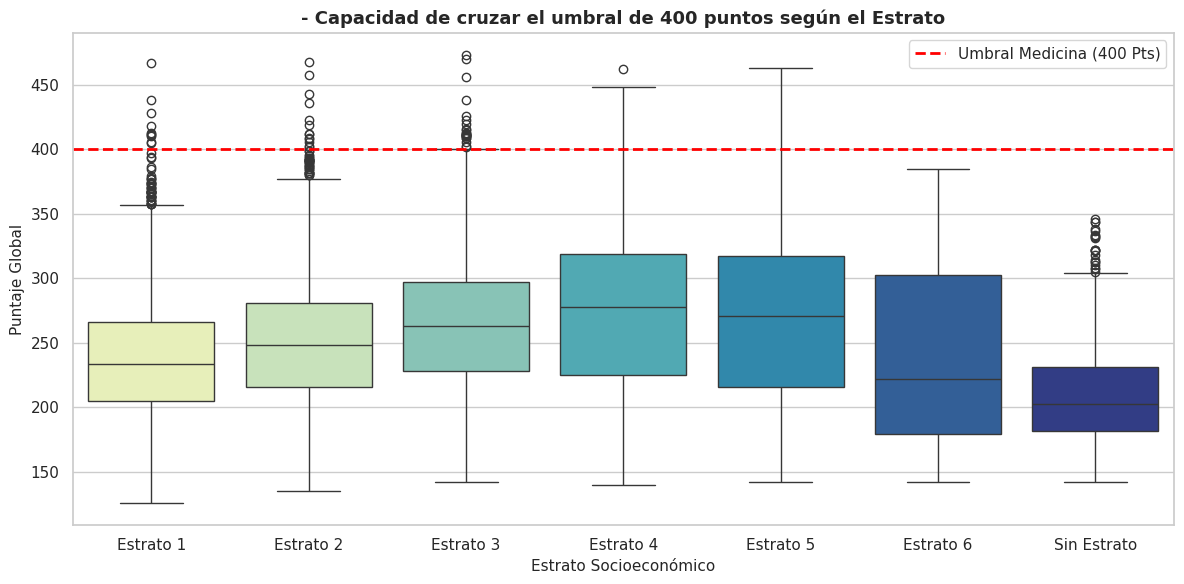

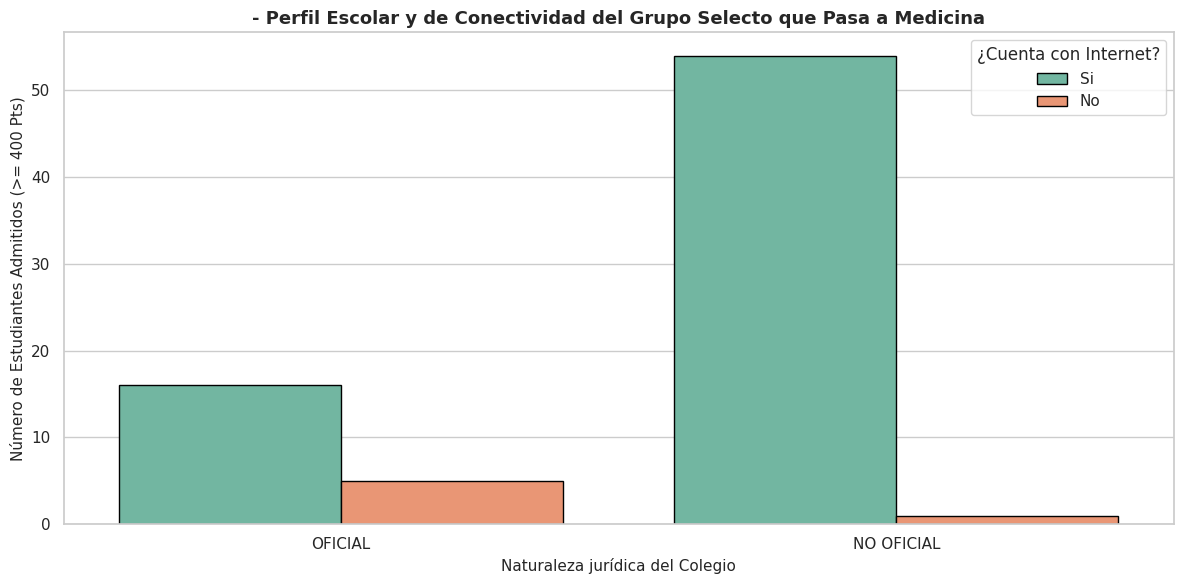

In [30]:
# d) analisis bivariado y multivariado
print("- Análisis Bivariado y Multivariado")

# 3.1 Relación Estrato Social vs Probabilidad de Admisión
print("Tasa de éxito para Medicina (>=400 puntos) según el Estrato de Vivienda:")
tabla_estrato = df.groupby('FAMI_ESTRATOVIVIENDA')['PASO_MEDICINA'].mean() * 100
print(tabla_estrato.round(3).astype(str) + " %")

# Gráfica Bivariada A: Caja (Estrato vs Puntaje)
plt.figure()
orden_estrato = sorted(df['FAMI_ESTRATOVIVIENDA'].dropna().unique())
sns.boxplot(x='FAMI_ESTRATOVIVIENDA', y='PUNT_GLOBAL', data=df, order=orden_estrato, palette="YlGnBu")
plt.axhline(y=400, color='red', linestyle='--', linewidth=2, label='Umbral Medicina (400 Pts)')
plt.title('- Capacidad de cruzar el umbral de 400 puntos según el Estrato', fontsize=13, fontweight='bold')
plt.xlabel('Estrato Socioeconómico', fontsize=11)
plt.ylabel('Puntaje Global', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# Gráfica Bivariada B: Barras cruzadas (Colegio e Internet vs Admisión)
plt.figure()
# Filtramos temporalmente la data para visualizar mejor la proporción de los que sí pasan
df_admitidos = df[df['PASO_MEDICINA'] == 1]
if len(df_admitidos) > 0:
    sns.countplot(x='COLE_NATURALEZA', hue='FAMI_TIENEINTERNET', data=df_admitidos, palette="Set2", edgecolor='black')
    plt.title('- Perfil Escolar y de Conectividad del Grupo Selecto que Pasa a Medicina', fontsize=13, fontweight='bold')
    plt.xlabel('Naturaleza jurídica del Colegio', fontsize=11)
    plt.ylabel('Número de Estudiantes Admitidos (>= 400 Pts)', fontsize=11)
    plt.legend(title='¿Cuenta con Internet?')
    plt.tight_layout()
    plt.show()
else:
    print("Nota: No se detectaron estudiantes con puntajes mayores o iguales a 400 en la muestra actual.")

In [31]:
# PREPROCESAMIENTO DE DATOS
# a) limpieza de datos
# Ejemplo: Imputar con la moda
df['FAMI_EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].fillna(df['FAMI_EDUCACIONMADRE'].mode()[0])
df['FAMI_ESTRATOVIVIENDA'] = df['FAMI_ESTRATOVIVIENDA'].fillna(df['FAMI_ESTRATOVIVIENDA'].mode()[0])

In [33]:
# b) codificacion de variables categoricas
# One-Hot Encoding para variables sin orden
df_pre = pd.get_dummies(df, columns=['ESTU_GENERO', 'COLE_NATURALEZA', 'FAMI_TIENEINTERNET'], drop_first=True)

In [35]:
# c) escalado de variables
scaler = StandardScaler()
cols_to_scale = ['PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA']
df_pre[cols_to_scale] = scaler.fit_transform(df_pre[cols_to_scale])

In [37]:
# d) division de datos
from sklearn.model_selection import train_test_split

X = df_pre.drop('PASO_MEDICINA', axis=1) # Predictores
y = df_pre['PASO_MEDICINA']              # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)